## Setup

In [1]:
import sys
import os
from pathlib import Path

project_root = Path("/Users/casey/Documents/PRACTICE/RAG Series/agentic_rag_L3")
os.chdir(project_root)
sys.path.insert(0, str(project_root))

from agentic_rag.config import get_settings
s = get_settings()
print(f"App: {s.app_name}")
print(f"Model: {s.ollama_model}")

App: AgenticRAG
Model: gemma4:e2b


## Parse with Docling

In [2]:
from agentic_rag.ingestion.loader import load_pdf

# First run downloads Docling models (~1-2 min), cached after that
doc = load_pdf("data/papers/attention_is_all_you_need.pdf")

print(f"\nFile: {doc.file_name}")
print(f"Pages: {doc.num_pages}")
print(f"Total chars: {len(doc.markdown_text):,}")
print(f"\n--- First 2000 chars ---")
print(doc.markdown_text[:2000])

  Parsing 'attention_is_all_you_need.pdf' with Docling...


Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

  Parsed: 15 pages, 48,967 chars

File: attention_is_all_you_need.pdf
Pages: 15
Total chars: 48,967

--- First 2000 chars ---
Provided proper attribution is provided, Google hereby grants permission to reproduce the tables and figures in this paper solely for use in journalistic or scholarly works.

## Attention Is All You Need

Ashish Vaswani ∗ Google Brain avaswani@google.com

Noam Shazeer ∗ Google Brain noam@google.com

Llion Jones ∗ Google Research llion@google.com

Niki Parmar ∗ Google Research nikip@google.com

Aidan N. Gomez ∗ † University of Toronto aidan@cs.toronto.edu

Jakob Uszkoreit ∗ Google Research usz@google.com

Łukasz Kaiser ∗ Google Brain lukaszkaiser@google.com

∗ ‡

Illia Polosukhin illia.polosukhin@gmail.com

## Abstract

The dominant sequence transduction models are based on complex recurrent or convolutional neural networks that include an encoder and a decoder. The best performing models also connect the encoder and decoder through an attention mechanism. We pro

### Docling vs pymupdf4llm

In [3]:
# Install pymupdf4llm temporarily for comparison
import pymupdf4llm

old_output = pymupdf4llm.to_markdown("data/papers/attention_is_all_you_need.pdf")
new_output = doc.markdown_text

print("=== pymupdf4llm (first 500 chars) ===")
print(old_output[:500])
print("\n=== Docling (first 500 chars) ===")
print(new_output[:500])

=== pymupdf4llm (first 500 chars) ===
Provided proper attribution is provided, Google hereby grants permission to reproduce the tables and figures in this paper solely for use in journalistic or scholarly works. 

# **Attention Is All You Need** 

**Ashish Vaswani** _[∗]_ **Noam Shazeer** _[∗]_ **Niki Parmar** _[∗]_ **Jakob Uszkoreit** _[∗]_ Google Brain Google Brain Google Research Google Research `avaswani@google.com noam@google.com nikip@google.com usz@google.com` 

**Llion Jones** _[∗]_ **Aidan N. Gomez** _[∗†]_ **Łukasz Kaiser*

=== Docling (first 500 chars) ===
Provided proper attribution is provided, Google hereby grants permission to reproduce the tables and figures in this paper solely for use in journalistic or scholarly works.

## Attention Is All You Need

Ashish Vaswani ∗ Google Brain avaswani@google.com

Noam Shazeer ∗ Google Brain noam@google.com

Llion Jones ∗ Google Research llion@google.com

Niki Parmar ∗ Google Research nikip@google.com

Aidan N. Gomez ∗ † University

## Chunk Documents via docling Hybrid chunker

In [4]:
from agentic_rag.ingestion.chunker import chunk_document

chunks = chunk_document(doc, max_tokens=512, collection="nlp")

print(f"Total chunks: {len(chunks)}")
print(f"\n--- Chunk 0 ---")
print(chunks[0].text)
print(f"\nMetadata: {chunks[0].metadata}")

Token indices sequence length is longer than the specified maximum sequence length for this model (968 > 512). Running this sequence through the model will result in indexing errors


  'attention_is_all_you_need.pdf' → 42 chunks (avg 1033 chars each)
Total chunks: 42

--- Chunk 0 ---
Provided proper attribution is provided, Google hereby grants permission to reproduce the tables and figures in this paper solely for use in journalistic or scholarly works.

Metadata: {'source': 'attention_is_all_you_need.pdf', 'file_path': '/Users/casey/Documents/PRACTICE/RAG Series/agentic_rag_L3/data/papers/attention_is_all_you_need.pdf', 'num_pages': 15, 'file_size_kb': 2163.32, 'chunk_index': 0, 'chunk_id': 'attention_is_all_you_need.pdf_chunk_0000', 'total_chunks': 42, 'collection': 'nlp'}


## Testing Collection Router

In [5]:
from agentic_rag.ingestion.collection_router import route_document

test_files = [
    ("attention_is_all_you_need.pdf", doc.markdown_text),
    ("resnet_image_classification.pdf", "convolutional neural network vision"),
    ("unknown_paper.pdf", ""),
]

for fname, content in test_files:
    collection = route_document(fname, content)
    print(f"{fname} → {collection}")

  Routed 'attention_is_all_you_need.pdf' → collection: 'nlp'
attention_is_all_you_need.pdf → nlp
  Routed 'resnet_image_classification.pdf' → collection: 'computer_vision'
resnet_image_classification.pdf → computer_vision
  Routed 'unknown_paper.pdf' → collection: 'general' (no match)
unknown_paper.pdf → general


In [6]:
for max_tok in [256, 512, 1024]:
    c = chunk_document(doc, max_tokens=max_tok, collection="nlp")
    avg = sum(len(ch.text) for ch in c) // len(c)
    print(f"max_tokens={max_tok:4d} | chunks={len(c):3d} | avg_chars={avg}")

# We go with max_tokens=512. 42 chunks for 15 pages is reasonable
# Rule of thumb: 1 token ≈ 4 chars ≈ 0.75 words. So 512 tokens ≈ 384 words ≈ 2048 chars. Our avg_chars of 1033 ≈ 258 words ≈ 344 tokens — well within the 512 limit, which explains why chunk count stayed the same between 512 and 1024.

Token indices sequence length is longer than the specified maximum sequence length for this model (968 > 512). Running this sequence through the model will result in indexing errors


  'attention_is_all_you_need.pdf' → 66 chunks (avg 657 chars each)
max_tokens= 256 | chunks= 66 | avg_chars=657


Token indices sequence length is longer than the specified maximum sequence length for this model (968 > 512). Running this sequence through the model will result in indexing errors


  'attention_is_all_you_need.pdf' → 42 chunks (avg 1033 chars each)
max_tokens= 512 | chunks= 42 | avg_chars=1033


Token indices sequence length is longer than the specified maximum sequence length for this model (968 > 512). Running this sequence through the model will result in indexing errors


  'attention_is_all_you_need.pdf' → 33 chunks (avg 1315 chars each)
max_tokens=1024 | chunks= 33 | avg_chars=1315


In [7]:
c[3].text

'Recurrent neural networks, long short-term memory [13] and gated recurrent [7] neural networks in particular, have been firmly established as state of the art approaches in sequence modeling and transduction problems such as language modeling and machine translation [35, 2, 5]. Numerous efforts have since continued to push the boundaries of recurrent language models and encoder-decoder architectures [38, 24, 15].\nRecurrent models typically factor computation along the symbol positions of the input and output sequences. Aligning the positions to steps in computation time, they generate a sequence of hidden states h t , as a function of the previous hidden state h t -1 and the input for position t . This inherently sequential nature precludes parallelization within training examples, which becomes critical at longer sequence lengths, as memory constraints limit batching across examples. Recent work has achieved significant improvements in computational efficiency through factorization 

In [8]:
# Clear Postgres Tables
# !docker exec -i stateful_rag_postgres psql -U docmind -d docmind -c "TRUNCATE TABLE documents, chat_messages, chat_summaries RESTART IDENTITY;"
# Flush Redis Cache
# !docker exec -i stateful_rag_redis redis-cli FLUSHALL

## Embed and store Chunks

In [9]:
from agentic_rag.ingestion.loader import load_pdf
from agentic_rag.ingestion.chunker import chunk_document
from agentic_rag.ingestion.collection_router import route_document
from agentic_rag.embeddings.embedder import embed_texts
from agentic_rag.vectorstore.pgvector_store import add_chunks, get_collection_stats

# Load + route
doc = load_pdf("data/papers/attention_is_all_you_need.pdf")
collection = route_document(doc.file_name, doc.markdown_text)

# Chunk with collection
chunks = chunk_document(doc, max_tokens=512, collection=collection)

# Embed
texts = [c.text for c in chunks]
print("Embedding chunks...")
embeddings = embed_texts(texts)
print(f"Embedded {len(embeddings)} vectors")

# Store
inserted = add_chunks(chunks, embeddings)
stats = get_collection_stats()
print(f"\nStats: {stats}")

  Parsing 'attention_is_all_you_need.pdf' with Docling...


Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

  Parsed: 15 pages, 48,967 chars
  Routed 'attention_is_all_you_need.pdf' → collection: 'nlp'


Token indices sequence length is longer than the specified maximum sequence length for this model (968 > 512). Running this sequence through the model will result in indexing errors


  'attention_is_all_you_need.pdf' → 42 chunks (avg 1033 chars each)
Embedding chunks...
Embedded 42 vectors
  Inserted 0 new chunks (42 already existed)

Stats: {'total_chunks': 42, 'sources': [{'source': 'nlp', 'chunks': 42}]}


In [10]:
from agentic_rag.embeddings.embedder import embed_query
from agentic_rag.vectorstore.pgvector_store import similarity_search

query = "How does multi-head attention work?"
query_vec = embed_query(query)

# Search within nlp collection only
results = similarity_search(query_vec, k=5, collection="nlp")
print(f"Results from 'nlp' collection: {len(results)}")
for r in results:
    print(f"  {r['chunk_id']} | sim={round(r['similarity'], 4)} | {r['content'][:80]}...")

print()

# Search all collections
results_all = similarity_search(query_vec, k=5)
print(f"Results from all collections: {len(results_all)}")

Results from 'nlp' collection: 5
  attention_is_all_you_need.pdf_chunk_0011 | sim=0.6932 | The Transformer uses multi-head attention in three different ways:
- In "encoder...
  attention_is_all_you_need.pdf_chunk_0041 | sim=0.6811 | Figure 3: An example of the attention mechanism following long-distance dependen...
  attention_is_all_you_need.pdf_chunk_0035 | sim=0.6465 | In this work, we presented the Transformer, the first sequence transduction mode...
  attention_is_all_you_need.pdf_chunk_0007 | sim=0.6377 | An attention function can be described as mapping a query and a set of key-value...
  attention_is_all_you_need.pdf_chunk_0010 | sim=0.6333 | Instead of performing a single attention function with d model-dimensional keys,...

Results from all collections: 5


In [11]:
from agentic_rag.vectorstore.pgvector_store import explain_query

plan = explain_query(query_vec, collection="nlp")
print(plan)
# Look for "Index Scan using idx_documents_embedding_hnsw"

Limit  (cost=8.18..8.18 rows=1 width=57) (actual time=0.153..0.155 rows=20 loops=1)
  Buffers: shared hit=204
  ->  Sort  (cost=8.18..8.18 rows=1 width=57) (actual time=0.153..0.153 rows=20 loops=1)
        Sort Key: ((embedding <=> '[-0.03780987,0.0036952116,-0.15429822,0.023921393,0.061434,-0.02109135,0.049470555,-0.016429879,0.026671164,0.0034320503,-0.029743463,-0.015557696,0.07684385,0.04918194,0.026482115,-0.008747548,-0.026763197,-0.07296169,-0.005996678,0.012851393,-0.037915014,0.03426235,0.0033835238,-0.013570693,0.031878475,0.05369292,-0.005629432,-0.00028658033,-0.05410647,0.01433604,0.05518692,-0.01207485,-0.037848644,-0.035240453,-0.032278173,-0.01304623,0.032023445,0.015982656,-0.063146494,0.07210584,-0.020888504,-0.022328533,-0.01705645,-0.0709032,0.0024306306,-0.0036565827,0.0710524,0.024673274,0.0644555,-0.060341246,0.034589507,-0.015049816,0.011780801,0.01536729,0.08193323,0.031011213,0.01347477,0.017748062,0.01109577,0.029220233,0.07528658,0.0065486394,0.011929049,0.

In [12]:
inserted2 = add_chunks(chunks, embeddings)
print(f"Second run inserted: {inserted2} (should be 0)")

  Inserted 0 new chunks (42 already existed)
Second run inserted: 0 (should be 0)


In [13]:
from agentic_rag.vectorstore.pgvector_store import get_available_collections

collections = get_available_collections()
print(f"Collections in DB: {collections}")

Collections in DB: ['nlp']


In [14]:
# Cross-encoder (what we're adding):

# Processes query and document together as one input
# Slower — full transformer forward pass per chunk
# Much more accurate — sees exact token interactions

# Why retrieve 20 then rerank to 4?
# Cross-encoder is too slow to run on the entire corpus (42 chunks × ~0.1s = 4s). Running it on just 20 candidates from pgvector takes ~2s and dramatically improves final top-4 quality.

## Load Cross Encoders

In [15]:
from agentic_rag.retrieval.reranker import get_cross_encoder

print("Loading cross-encoder...")
encoder = get_cross_encoder()
print(f"Model loaded: {encoder.model.config.name_or_path}")

Loading cross-encoder...


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded: cross-encoder/ms-marco-MiniLM-L-6-v2


## RE-ranking exp

# Bi-Encoders vs. Cross-Encoders in Neural Retrieval

Bi-Encoders produce for a given sentence a sentence embedding.

Cross-Encoder, we pass both sentences simultaneously to the Transformer network. It produces then an output value between 0 and 1 indicating the similarity of the input sentence pair:

![Bi-Encoder vs Cross-Encoder](https://raw.githubusercontent.com/huggingface/sentence-transformers/main/docs/img/Bi_vs_Cross-Encoder.png)


Bi-Encoders (see Computing Sentence Embeddings) are used whenever you need a sentence embedding in a vector space for efficient comparison. Applications are for example Information Retrieval / Semantic Search or Clustering. Cross-Encoders would be the wrong choice for these application: Clustering 10,000 sentence with CrossEncoders would require computing similarity scores for about 50 Million sentence combinations, which takes about 65 hours. With a Bi-Encoder, you compute the embedding for each sentence, which takes only 5 seconds. You can then perform the clustering.

Cross-Encoder achieve higher performance than Bi-Encoders, however, they do not scale well for large datasets. Here, it can make sense to combine Cross- and Bi-Encoders, for example in Information Retrieval / Semantic Search scenarios: First, you use an efficient Bi-Encoder to retrieve e.g. the top-100 most similar sentences for a query. Then, you use a Cross-Encoder to re-rank these 100 hits by computing the score for every (query, hit) combination.


*Source: https://sbert.net/examples/cross_encoder/applications/README.html*

---

## 1. Problem Definition

### Bi-Encoder (Nomic Embed)
* **Input:** Two independent sequences: a Query ($Q$) and a Document ($D$). These are processed separately through the model.
* **Output:** A fixed-size vector representation (an embedding) for both the Query and the Document. The ultimate goal is to calculate the **Cosine Similarity** (a measure of how much two vectors point in the same direction) between these two vectors.

### Cross-Encoder (MS-MARCO MiniLM)
* **Input:** A single concatenated pair: `[CLS] Query [SEP] Document [SEP]`. Both sequences are fed into the model simultaneously, allowing for full self-attention across both texts.
* **Output:** A single scalar value (a score, typically between 0 and 1) representing the **Relevancy Probability** (the likelihood that the document is the correct answer to the query).

---

## 2. Model Architecture

### Bi-Encoder (Nomic Embed)
* **Architecture:** Based on the BERT architecture (Bidirectional Encoder Representations from Transformers), but optimized for long-context (8k tokens). It uses a "Siamese" or "Dual-Encoder" setup.
* **Mechanism:** It maps text into a **Latent Vector Space** (a multidimensional mathematical space where similar meanings are positioned close together).
* **Performance:** Extremely fast for retrieval because Document embeddings can be pre-calculated and stored in a Vector Database (like your pgvector setup).

### Cross-Encoder (ms-marco-MiniLM-L6-v2)
* **Architecture:** A standard Transformer architecture where the Query and Document interact in every layer.
* **Mechanism:** Uses **Cross-Attention** (a mechanism where every word in the Query can look at every word in the Document to find relationships).
* **Performance:** Very slow but highly accurate. It cannot pre-calculate embeddings because the score depends on the specific pairing of $Q$ and $D$. It is typically used for **Reranking** (re-ordering a small list of documents found by the Bi-Encoder).

---

## 3. Mathematical Formulation

### Bi-Encoder
The model acts as an encoding function $\phi$:
$$E_q = \phi(Q), \quad E_d = \phi(D)$$
The similarity score $S$ is computed using the Dot Product or Cosine Similarity:
$$S(Q, D) = \frac{E_q \cdot E_d}{\|E_q\| \|E_d\|}$$
*(This formula means: The score is the product of the vectors divided by their lengths, which cancels out the effect of text length and focuses only on the angle/meaning.)*

### Cross-Encoder
The model acts as a classification function $f$:
$$S(Q, D) = \sigma(W \cdot \text{Transformer}(Q, D) + b)$$
*(This formula means: The Transformer processes the pair, and the output is passed through a Linear Layer ($W, b$) and a Sigmoid function ($\sigma$) to squeeze the result into a probability score.)*

---

## 4. Training Objective

### Bi-Encoder (Nomic)
* **Dataset:** Trained on massive collections of paired text (e.g., Wikipedia, StackOverflow) and fine-tuned on contrastive datasets.
* **Loss Function:** **Contrastive Loss** or **InfoNCE Loss**.
    * *Concept:* The model is taught to minimize the distance between "Positive" pairs (Query and its correct Answer) while maximizing the distance from "Negative" pairs (Query and a random, incorrect document).
  The Bi-Encoder utilizes **InfoNCE (Information Noise Contrastive Estimation)**, which is designed to optimize the distance between embeddings in a high-dimensional space.
    $$L = -\log \frac{\exp(\text{sim}(q, p^+) / \tau)}{\sum_{i=0}^{n} \exp(\text{sim}(q, p_i) / \tau)}$$
  * **Mechanics:**
      * **Numerator:** Maximizes the similarity between the query ($q$) and the positive document ($p^+$).
      * **Denominator:** Sums the similarities of the query against all documents in the batch ($n$ negatives).
      * **Temperature Parameter ($\tau$):** A scaling factor that controls how "sharply" the model punishes negative examples (higher values smooth the distribution, lower values make it more sensitive to small differences).
      * **In-Batch Negatives:** In practice, the model uses other positive pairs within the same training batch as "negatives" to increase computational efficiency.

### Cross-Encoder (MS-MARCO MiniLM)
* **Dataset:** Specifically fine-tuned on the **MS-MARCO** dataset (Microsoft Machine Reading Comprehension), which contains real-world Bing search queries and expert-labeled relevant passages.
* **Loss Function:** **Binary Cross-Entropy (BCE) Loss**.
    * *Concept:* For every pair $(Q, D)$, the model is treated as a binary classifier: "Is this document relevant (1) or not (0)?" It penalizes the model based on the difference between the predicted probability and the true 0/1 label.
     $$L = -\frac{1}{N} \sum_{i=1}^{N} [y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i)]$$
  * **Mechanics:**
      * **Predicted Probability ($\hat{y}$):** The output of the model after the Sigmoid function (a value between 0 and 1).
      * **Ground Truth ($y$):** A hard label where 1 represents a relevant pair and 0 represents an irrelevant pair.
      * **Logarithmic Penalty:** The loss increases exponentially as the predicted probability diverges from the actual label (e.g., if the model predicts 0.1 for a relevant document, the penalty is severe).
      * **Point-wise Processing:** Unlike the Bi-Encoder, which compares one positive against many negatives simultaneously, the Cross-Encoder calculates loss for each individual Query-Document pair independently.


   

### Stage 1: bi-encoder retrieval

In [16]:
from agentic_rag.retrieval.retriever import retrieve
import time

question = "How does multi-head attention work?"

start = time.time()
candidates = retrieve(question, collection="nlp", k=20)
bi_time = round(time.time() - start, 3)

print(f"Bi-encoder retrieved {len(candidates)} candidates in {bi_time}s")
print(f"\nTop 5 by similarity score:")
for r in candidates[:5]:
    print(f"  sim={round(r['similarity'], 4)} | {r['chunk_id']} | {r['content'][:80]}...")

Bi-encoder retrieved 20 candidates in 0.061s

Top 5 by similarity score:
  sim=0.6932 | attention_is_all_you_need.pdf_chunk_0011 | The Transformer uses multi-head attention in three different ways:
- In "encoder...
  sim=0.6811 | attention_is_all_you_need.pdf_chunk_0041 | Figure 3: An example of the attention mechanism following long-distance dependen...
  sim=0.6465 | attention_is_all_you_need.pdf_chunk_0035 | In this work, we presented the Transformer, the first sequence transduction mode...
  sim=0.6377 | attention_is_all_you_need.pdf_chunk_0007 | An attention function can be described as mapping a query and a set of key-value...
  sim=0.6333 | attention_is_all_you_need.pdf_chunk_0010 | Instead of performing a single attention function with d model-dimensional keys,...


### Stage 2: cross-encoder reranking

In [17]:
from agentic_rag.retrieval.reranker import rerank

start = time.time()
reranked = rerank(question, candidates, top_n=4)
rerank_time = round(time.time() - start, 3)

print(f"Cross-encoder reranked to top-4 in {rerank_time}s")
print(f"\nTop 4 after reranking:")
for r in reranked:
    print(f"  rerank={round(r['rerank_score'], 4)} | sim={round(r['similarity'], 4)} | {r['chunk_id']}")
    print(f"  {r['content'][:120]}...")
    print()

Cross-encoder reranked to top-4 in 0.296s

Top 4 after reranking:
  rerank=6.9654 | sim=0.6231 | attention_is_all_you_need.pdf_chunk_0008
  Figure 2: (left) Scaled Dot-Product Attention. (right) Multi-Head Attention consists of several attention layers running...

  rerank=6.3838 | sim=0.6932 | attention_is_all_you_need.pdf_chunk_0011
  The Transformer uses multi-head attention in three different ways:
- In "encoder-decoder attention" layers, the queries ...

  rerank=4.6542 | sim=0.6333 | attention_is_all_you_need.pdf_chunk_0010
  Instead of performing a single attention function with d model-dimensional keys, values and queries, we found it benefic...

  rerank=2.4429 | sim=0.5504 | attention_is_all_you_need.pdf_chunk_0006
  Encoder: The encoder is composed of a stack of N = 6 identical layers. Each layer has two sub-layers. The first is a mul...



**Compare bi-encoder vs reranked order**

In [18]:
print("=== ORDER COMPARISON ===")
print(f"\n{'Rank':<6} {'Bi-encoder':^45} {'After Reranking':^45}")
print("-" * 96)

bi_ids = [r['chunk_id'].split('_chunk_')[1] for r in candidates[:8]]
re_ids = [r['chunk_id'].split('_chunk_')[1] for r in reranked]

for i in range(max(len(bi_ids), len(re_ids))):
    bi = bi_ids[i] if i < len(bi_ids) else ""
    re = re_ids[i] if i < len(re_ids) else ""
    marker = " ← moved up" if re not in bi_ids[:i+1] and i < len(re_ids) else ""
    print(f"  {i+1:<4} chunk_{bi:<40} chunk_{re}{marker}")

=== ORDER COMPARISON ===

Rank                    Bi-encoder                                  After Reranking               
------------------------------------------------------------------------------------------------
  1    chunk_0011                                     chunk_0008 ← moved up
  2    chunk_0041                                     chunk_0011
  3    chunk_0035                                     chunk_0010 ← moved up
  4    chunk_0007                                     chunk_0006 ← moved up
  5    chunk_0010                                     chunk_
  6    chunk_0008                                     chunk_
  7    chunk_0004                                     chunk_
  8    chunk_0002                                     chunk_


## Full two-stage pipeline

In [19]:
from agentic_rag.retrieval.reranker import retrieve_and_rerank

questions = [
    "How does multi-head attention work?",
    "What BLEU score did the Transformer achieve?",
    "Why did the authors remove recurrence?",
]

for q in questions:
    results = retrieve_and_rerank(q, collection="nlp")
    print(f"Q: {q}")
    for r in results:
        print(f"  [{round(r['rerank_score'], 3)}] {r['chunk_id']}: {r['content'][:80]}...")
    print()

Q: How does multi-head attention work?
  [6.965] attention_is_all_you_need.pdf_chunk_0008: Figure 2: (left) Scaled Dot-Product Attention. (right) Multi-Head Attention cons...
  [6.384] attention_is_all_you_need.pdf_chunk_0011: The Transformer uses multi-head attention in three different ways:
- In "encoder...
  [4.654] attention_is_all_you_need.pdf_chunk_0010: Instead of performing a single attention function with d model-dimensional keys,...
  [2.443] attention_is_all_you_need.pdf_chunk_0006: Encoder: The encoder is composed of a stack of N = 6 identical layers. Each laye...

Q: What BLEU score did the Transformer achieve?
  [6.641] attention_is_all_you_need.pdf_chunk_0025: On the WMT 2014 English-to-German translation task, the big transformer model (T...
  [6.327] attention_is_all_you_need.pdf_chunk_0022: Table 2: The Transformer achieves better BLEU scores than previous state-of-the-...
  [4.269] attention_is_all_you_need.pdf_chunk_0002: The dominant sequence transduction models ar

In [20]:
import time

question = "What is positional encoding?"

# Bi-encoder only
start = time.time()
bi_results = retrieve(question, collection="nlp", k=4)
bi_only_time = round(time.time() - start, 3)

# Full two-stage
start = time.time()
full_results = retrieve_and_rerank(question, collection="nlp")
full_time = round(time.time() - start, 3)

print(f"Bi-encoder only (k=4):     {bi_only_time}s")
print(f"Two-stage (k=20 + rerank): {full_time}s")
print(f"Latency cost of reranking: {round(full_time - bi_only_time, 3)}s")
print(f"\nTop result bi-encoder:  {bi_results[0]['chunk_id']}")
print(f"Top result after rerank: {full_results[0]['chunk_id']}")

Bi-encoder only (k=4):     0.047s
Two-stage (k=20 + rerank): 0.245s
Latency cost of reranking: 0.198s

Top result bi-encoder:  attention_is_all_you_need.pdf_chunk_0014
Top result after rerank: attention_is_all_you_need.pdf_chunk_0014


## Test Graders (LLM-as-judge)

In [21]:
# Grading Context Quality

from agentic_rag.agent.graders import grade_context 
from agentic_rag.retrieval.reranker import retrieve_and_rerank

question = "How does multi-head attention work?"
chunks = retrieve_and_rerank(question, collection="nlp")

# Format context same way the agent will
context = "\n\n---\n\n".join([
    f"[{c['chunk_id']}]\n{c['content']}"
    for c in chunks
])

print("Grading context quality...")
grade = grade_context(question, context)
print(f"Sufficient: {grade.sufficient}")
print(f"Reason: {grade.reason}")

Grading context quality...
Sufficient: True
Reason: The context explains that multi-head attention involves performing attention in parallel across different representation subspaces to jointly attend to information from different positions.


In [22]:
# Grading Context Quality

# Simulate retrieving irrelevant chunks
bad_context = """
[chunk_0001]
The weather in San Francisco is often foggy in summer.

[chunk_0002]
Python was created by Guido van Rossum in 1991.
"""

grade_bad = grade_context(question, bad_context)
print(f"Bad context — Sufficient: {grade_bad.sufficient}")
print(f"Reason: {grade_bad.reason}")
# Should be False

Bad context — Sufficient: False
Reason: The provided context does not contain any information about how multi-head attention works.


In [23]:
# Faithful Answer Grading

from agentic_rag.agent.graders import grade_answer

# Good answer grounded in context
good_answer = """
Multi-head attention works by running h parallel attention functions on different 
linear projections of queries, keys and values [chunk_0008]. This allows the model 
to jointly attend to information from different representation subspaces at different 
positions [chunk_0010].
"""

grade = grade_answer(question, context, good_answer)
print(f"Faithful answer — Faithful: {grade.faithful}")
print(f"Reason: {grade.reason}")

Faithful answer — Faithful: True
Reason: The answer accurately summarizes the core mechanism of multi-head attention as described in the provided context.


In [24]:
# Answer that adds information not in the context
hallucinated_answer = """
Multi-head attention uses 16 parallel attention heads by default. 
Each head uses a separate GPU for computation. The mechanism was 
invented by Yoshua Bengio in 2015 at the University of Montreal.
"""

grade_bad = grade_answer(question, context, hallucinated_answer)
print(f"Hallucinated answer — Faithful: {grade_bad.faithful}")
print(f"Reason: {grade_bad.reason}")
# Should be False

Hallucinated answer — Faithful: False
Reason: The provided context does not contain information about the default number of attention heads, GPU usage, or the inventor of multi-head attention.


In [25]:
import time

start = time.time()
grade_context(question, context)
ctx_time = round(time.time() - start, 2)

start = time.time()
grade_answer(question, context, good_answer)
ans_time = round(time.time() - start, 2)

print(f"Context grader: {ctx_time}s")
print(f"Answer grader:  {ans_time}s")
print(f"Total grading:  {round(ctx_time + ans_time, 2)}s")
print(f"\nNote: Both graders add ~{round(ctx_time + ans_time, 2)}s to pipeline latency")

Context grader: 11.22s
Answer grader:  11.24s
Total grading:  22.46s

Note: Both graders add ~22.46s to pipeline latency


## Build the Graph

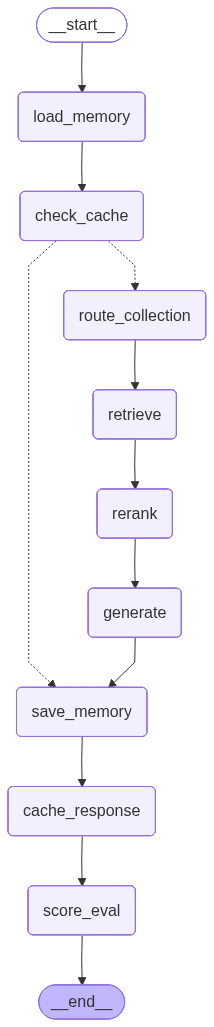

In [26]:
from agentic_rag.agent.graph import build_graph
from IPython.display import Image, display
from langchain_core.runnables.graph import CurveStyle, MermaidDrawMethod, NodeStyles

graph = build_graph()
# print(graph.get_graph().draw_ascii())

# Display Mermaid diagram as PNG
display(Image(graph.get_graph().draw_mermaid_png()))

## First Agent Call

In [27]:
from agentic_rag.agent.graph import ask
import time

start = time.time()
result = ask(
    question="How does multi-head attention work?",
    user_id="dave",
    session_id="session_001",
)
elapsed = round(time.time() - start, 2)

print(f"Cache hit: {result['cache_hit']}")
print(f"Trace ID: {result['trace_id']}")
print(f"Time: {elapsed}s")
print(f"\nAnswer:\n{result['answer']}")
print(f"\nSources:")
for s in result['sources']:
    print(f"  [{s['rerank_score']}] {s['chunk_id']}")

  Cache HIT (distance=0.0)
Cache hit: True
Trace ID: 73d8f5dfc2cb47de952219ed138d56fd
Time: 2.05s

Answer:
Multi-head attention works by performing several attention layers in parallel (`attention_is_all_you_need.pdf_chunk_0008`).

The process involves the following steps:

1.  **Linear Projection:** Instead of a single attention function, the queries, keys, and values are linearly projected $h$ times using different, learned linear projections to $d_k$, $d_k$, and $d_v$ dimensions, respectively (`attention_is_all_you_need.pdf_chunk_0010`).
2.  **Parallel Attention:** The attention function is then performed in parallel on these projected versions of the queries, keys, and values, which yields $d_v$-dimensional output values (`attention_is_all_you_need.pdf_chunk_0010`).
3.  **Concatenation and Projection:** These output values are concatenated and subsequently projected, resulting in the final values (`attention_is_all_you_need.pdf_chunk_0010`).

This mechanism allows the model to join

## Cache Hit Test

In [28]:
start = time.time()
result2 = ask(
    question="Explain multi-head attention mechanism",
    user_id="mike",
    session_id="session_001",
)
elapsed = round(time.time() - start, 2)

print(f"Cache hit: {result2['cache_hit']}")
print(f"Time: {elapsed}s")

  Cache HIT (distance=0.0864)
Cache hit: True
Time: 1.15s


## Multi-turn Memory Test

In [29]:
# Dave asks a follow-up
result3 = ask(
    question="What did you just tell me about attention heads?",
    user_id="dave",
    session_id="session_001",
)
print(f"Cache hit: {result3['cache_hit']}")
print(f"\nAnswer:\n{result3['answer']}")
# Should reference previous answer via memory

  Cache HIT (distance=0.0)
Cache hit: True

Answer:
Multi-head attention involves several attention layers running in parallel (`attention_is_all_you_need.pdf_chunk_0008`).

Key aspects related to attention heads include:

*   **Function:** Multi-head attention allows the model to jointly attend to information from different representation subspaces at different positions (`attention_is_all_you_need.pdf_chunk_0010`).
*   **Task Learning:** Different attention heads have been shown to learn to perform different tasks (`attention_is_all_you_need.pdf_chunk_0041`).
*   **Weight Calculation:** The weight assigned to each value is computed by a compatibility function of the query with the corresponding key (`attention_is_all_you_need.pdf_chunk_0008`).


In [30]:
# Checking Langfuse dashboard for the above trace

# from agentic_rag.observability.langfuse_client import verify_langfuse_connection
# verify_langfuse_connection()
# print(f"\nTrace ID to find in dashboard: {result['trace_id']}")